# Heuristic Optimization

In [1]:
import soiling_model as sm
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import (rcParams,dates,colors)
rcParams['figure.figsize'] = (15, 7)

In [2]:
data_folder = 'data/'
temp_file_folder = 'tmp/' (you might need to create tmp/ since it is in the .gitignore)
params = data_folder+'parameters.xlsx'
historical_files = [data_folder+'woomera_data.xlsx']  # could have multiple files here
SF = data_folder+'SF_woomera_SolarPILOT.csv'            # solar field of 48 sectors located in Woomera
climate_file = data_folder+'woomera_location_modified.epw'

n_az = 8        # number of azimuth partitions for the field sectors
n_rad = 6       # number of radial partitions for the field sectors
n_sol_az = 10   # number of solar azimuth angles for the efficiency lookup table
n_sol_el = 10   # number of solar elevation angles for the efficiency lookup table
second_surface = False # second_surface = False uses a first-surface model for the reflectance loss
number_of_sectors_cleaned_per_truck = 1 # number of sectors cleaned in a day by one truck
dust_type = "PM10"
num_samples = None # int or "None". If int, sample days from historical data
delete_samples = True # True to delete the generated sample files after simulation


Set on_disk = True to save some memory-intensive matrices to disk rather than memory. 

In [ ]:
on_disk = False # True saves some large matrices in the tmp/ folder (you might need to create tmp/ since it is in the .gitignore)

Generate random weather data dust concentration time series by randomly sampling days from historical database

In [3]:
if num_samples != None:
    sm.sample_simulation_inputs(historical_files,sheet_name="Weather",\
        N_sample_years=num_samples,output_file_format=temp_file_folder+"sample_{0:d}.xlsx")
    weather_files = [temp_file_folder+"sample_"+str(ii)+".xlsx" for ii in range(num_samples)]
else:
    weather_files = historical_files

Building sample 1 of 50
Building sample 2 of 50
Building sample 3 of 50
Building sample 4 of 50
Building sample 5 of 50
Building sample 6 of 50
Building sample 7 of 50
Building sample 8 of 50
Building sample 9 of 50
Building sample 10 of 50
Building sample 11 of 50
Building sample 12 of 50
Building sample 13 of 50
Building sample 14 of 50
Building sample 15 of 50
Building sample 16 of 50
Building sample 17 of 50
Building sample 18 of 50
Building sample 19 of 50
Building sample 20 of 50
Building sample 21 of 50
Building sample 22 of 50
Building sample 23 of 50
Building sample 24 of 50
Building sample 25 of 50
Building sample 26 of 50
Building sample 27 of 50
Building sample 28 of 50
Building sample 29 of 50
Building sample 30 of 50
Building sample 31 of 50
Building sample 32 of 50
Building sample 33 of 50
Building sample 34 of 50
Building sample 35 of 50
Building sample 36 of 50
Building sample 37 of 50
Building sample 38 of 50
Building sample 39 of 50
Building sample 40 of 50
Building 

Build soiling model, import inputs, and sectorize the field

Importing constants
Importing dust
Importing full solar field and sectorizing with 8 angular and 6 radial sectors
Importing site data (weather,time). Using dust_type = PM10, test_length = 8760 hours
Length of simulation for file tmp/sample_0.xlsx: 365.0 days
No rain intensity data to import.
Importing site data (weather,time). Using dust_type = PM10, test_length = 8760 hours
Length of simulation for file tmp/sample_1.xlsx: 365.0 days
No rain intensity data to import.
Importing site data (weather,time). Using dust_type = PM10, test_length = 8760 hours
Length of simulation for file tmp/sample_2.xlsx: 365.0 days
No rain intensity data to import.
Importing site data (weather,time). Using dust_type = PM10, test_length = 8760 hours
Length of simulation for file tmp/sample_3.xlsx: 365.0 days
No rain intensity data to import.
Importing site data (weather,time). Using dust_type = PM10, test_length = 8760 hours
Length of simulation for file tmp/sample_4.xlsx: 365.0 days
No rain intensity data to

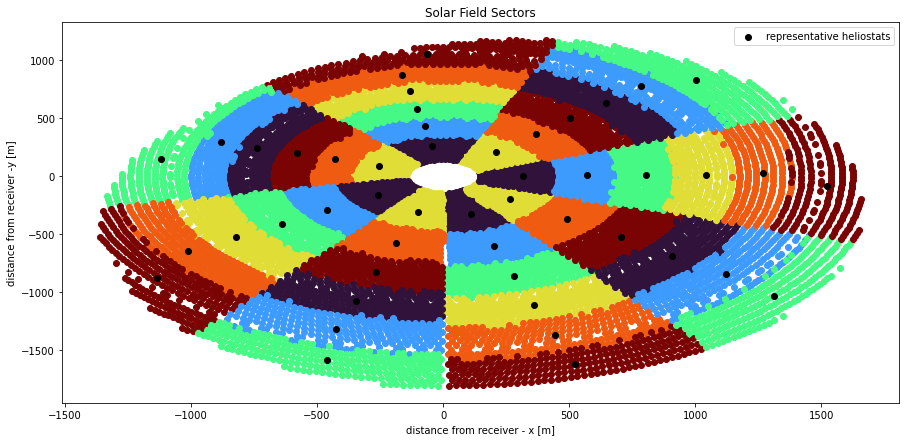

In [4]:
sec = (n_rad,n_az)
opt = sm.cleaning_optimisation(params,SF,weather_files,climate_file,sec,dust_type=dust_type,\
    second_surface=second_surface,n_az=n_sol_az,n_el=n_sol_el,on_disk=on_disk,path="tmp/")
opt.field_model.helios.sector_plot()

# delete sample files if they were generated
if delete_samples and (num_samples!=None):
    for f in weather_files:
        os.remove(f)

if on_disk: # delete temporary files of pdfqN to save disk space
    opt.field_model.helios.delete_temporary_files()

(<AxesSubplot:xlabel='D [$\\mu$m]', ylabel='$\\frac{dN [cm^{{-3}} ] }{dLog(D \\;[\\mu m])}$'>,
 <AxesSubplot:title={'center':'Number and Mass PDFs'}, ylabel='$\\frac{dm \\; [\\mu g \\, m^{{-3}} ] }{dLog(D \\; [\\mu m])}$'>)

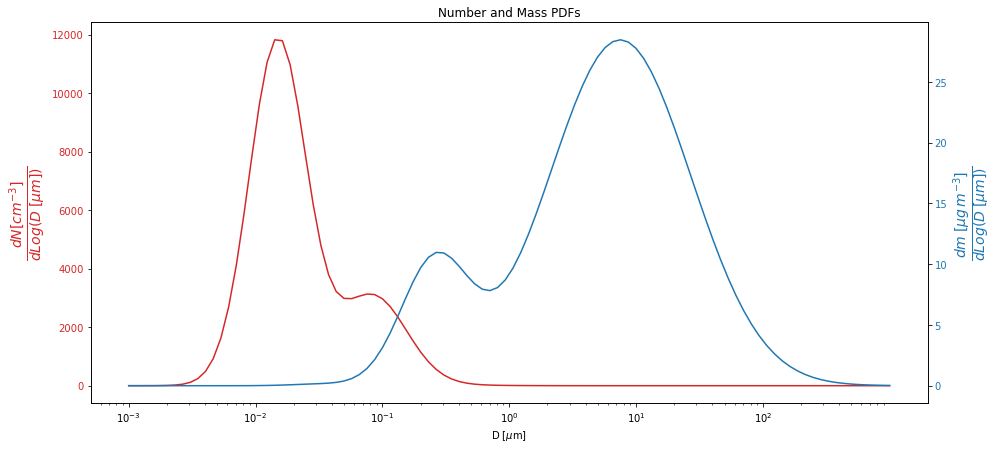

In [5]:
opt.field_model.dust.plot_distributions()

Grid search number of trucks and annual cleans to optimize cleaning resources and frequencies.

In [6]:
helio_area = opt.field_model.helios.height*opt.field_model.helios.width
n_helios = opt.field_model.helios.full_field['x'].shape[0]
area_per_sector = n_helios/n_az/n_rad*helio_area
opt.truck = {   'operator_salary':80e3,
                'operators_per_truck_per_day':4,
                'purchase_cost':150e3,
                'maintenance_costs':15e3,
                'useful_life': 4,
                'fuel_cost': 0.005*area_per_sector,
                'water_cost': 0.005*area_per_sector
            }
opt.electricty_price = 50/1e6
opt.plant_other_maintenace = 0.0
opt.plant.receiver['thermal_max'] = 1e3 # MW
opt.plant.receiver['thermal_min'] = 105 # MW

Optimize via grid search on number of trucks and number of field cleans in a year

In [7]:
Nt = range(1,10)
Nc = range(1,51)
TCC = np.nan*np.ones((len(Nt),len(Nc)))
for ii in range(len(Nt)):
    n_trucks = Nt[ii]
    for jj in range(len(Nc)):
        n_cleans = Nc[jj]
        print("Simulating {0:d} trucks with {1:d} cleans".format(n_trucks,n_cleans))
        results = opt.compute_total_cleaning_costs(n_trucks,n_cleans,\
            n_sectors_per_truck=number_of_sectors_cleaned_per_truck,verbose=False)
        number_of_cleaning_finishes = results['cleaning_actions'][0].sum(axis=1)[-1]
        if  number_of_cleaning_finishes < n_cleans:
            print("Cleans maxed out")
            break
        else:
            TCC[ii,jj] = results['total_cleaning_costs'].mean()

Simulating 1 trucks with 1 cleans
Simulating 1 trucks with 2 cleans
Simulating 1 trucks with 3 cleans
Simulating 1 trucks with 4 cleans
Simulating 1 trucks with 5 cleans
Simulating 1 trucks with 6 cleans
Simulating 1 trucks with 7 cleans
Simulating 1 trucks with 8 cleans
Cleans maxed out
Simulating 2 trucks with 1 cleans
Simulating 2 trucks with 2 cleans
Simulating 2 trucks with 3 cleans
Simulating 2 trucks with 4 cleans
Simulating 2 trucks with 5 cleans
Simulating 2 trucks with 6 cleans
Simulating 2 trucks with 7 cleans
Simulating 2 trucks with 8 cleans
Simulating 2 trucks with 9 cleans
Simulating 2 trucks with 10 cleans
Simulating 2 trucks with 11 cleans
Simulating 2 trucks with 12 cleans
Simulating 2 trucks with 13 cleans
Simulating 2 trucks with 14 cleans
Simulating 2 trucks with 15 cleans
Simulating 2 trucks with 16 cleans
Cleans maxed out
Simulating 3 trucks with 1 cleans
Simulating 3 trucks with 2 cleans
Simulating 3 trucks with 3 cleans
Simulating 3 trucks with 4 cleans
Simulat

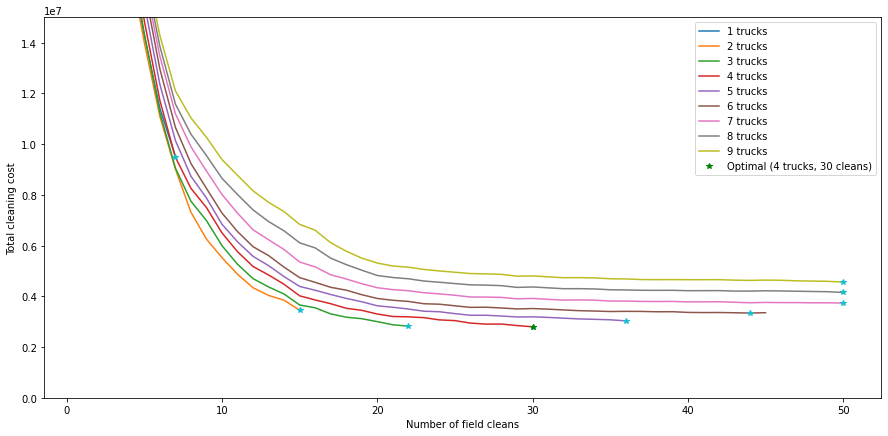

In [8]:
fig,ax = plt.subplots()
num_cleans = np.arange(start=Nc[0],stop=Nc[-1]+1)
for ii in Nt:
    ax.plot(num_cleans,TCC[ii-1,:],label=str(ii)+" trucks")

# optimal for each number of trucks
nc_opt = np.nanargmin(TCC,axis=1)
ax.plot(num_cleans[nc_opt],TCC[range(len(Nt)),nc_opt],linestyle="None",marker='*')

# overall optimal
nc_opt = np.nanargmin(TCC)
r,c = np.unravel_index(nc_opt,TCC.shape)
label_str = "Optimal ({0:d} trucks, {1:d} cleans)".format(r+1,c+1)
ax.plot(num_cleans[c],TCC[r,c],color='green',linestyle="None",marker='*',label=label_str)

ax.set_xlabel("Number of field cleans")
ax.set_ylabel("Total cleaning cost")
ax.set_ylim((0,15e6))
ax.legend()

Calculating reflectance losses with cleaning for 50 simulations
Number of time steps where sun is above stow elevation:3752.0 (10.0 degrees)
Number of time steps where clean receiver would be on: 3047
Number of time steps where actual receiver is on: 3047
Number of time steps where clean receiver would be saturated: 0
Number of time steps where actual receiver is saturated: 0
Results for simulation 0: 
  TCC: 2.74e+06
  C_deg: 8.76e+05
  C_cl: 1.87e+06
Number of time steps where sun is above stow elevation:3752.0 (10.0 degrees)
Number of time steps where clean receiver would be on: 3103
Number of time steps where actual receiver is on: 3101
Number of time steps where clean receiver would be saturated: 0
Number of time steps where actual receiver is saturated: 0
Results for simulation 1: 
  TCC: 2.65e+06
  C_deg: 7.85e+05
  C_cl: 1.87e+06
Number of time steps where sun is above stow elevation:3752.0 (10.0 degrees)
Number of time steps where clean receiver would be on: 3043
Number of tim

1440.0

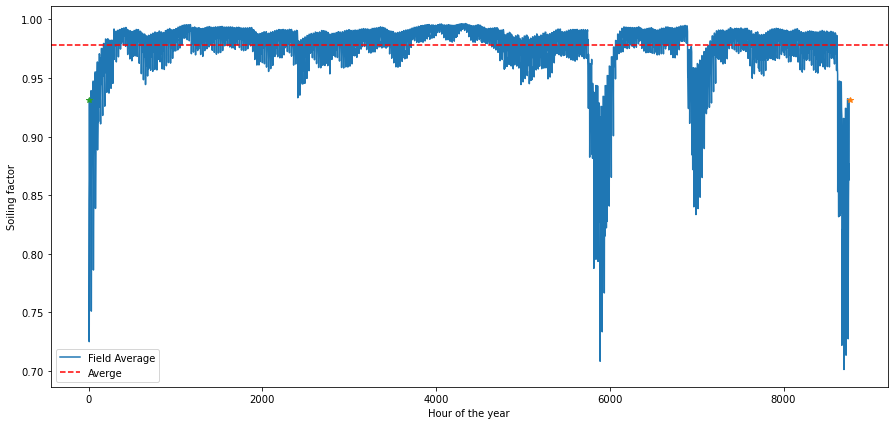

In [9]:
results_opt = opt.compute_total_cleaning_costs(r+1,c+1,\
    n_sectors_per_truck=number_of_sectors_cleaned_per_truck,verbose=True)
nh,nt = results['soiling_factor'][0].shape
fig,ax = plt.subplots()
sf = results['soiling_factor'][0]
ax.plot(sf.mean(axis=0),label="Field Average")
ax.plot(nt-1,sf[:,0].mean(),'*')
ax.plot(0,sf[:,-1].mean(),'*')
ax.axhline(y=sf.mean(),color='red',ls='--',label="Averge")
ax.set_xlabel("Hour of the year")
ax.set_ylabel("Soiling factor")
ax.legend()
results_opt['cleaning_actions'][0].sum()


Results for optimum

In [10]:
results = opt.compute_total_cleaning_costs(r+1,c+1,verbose=False)
cleans = results['cleaning_actions'][0] # same for all runs
"Number of cleans: {0:.1f}".format(cleans.sum())

'Number of cleans: 1440.0'

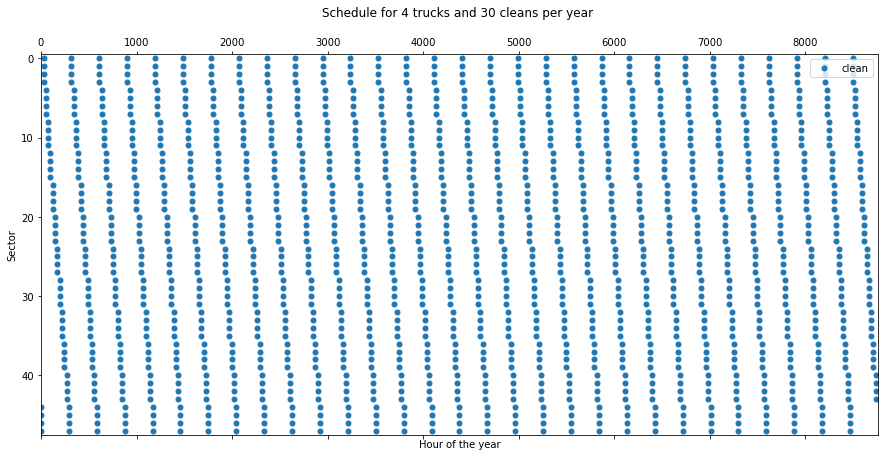

In [11]:
ax = plt.subplot()
ax.spy(cleans,aspect='auto',marker='.',label="clean")
ax.set_xlabel("Hour of the year")
ax.set_ylabel("Sector")
ax.set_title("Schedule for {0:d} trucks and {1:d} cleans per year \n".format(r+1,c+1))
ax.legend()

Text(0.5, 1.0, 'Soiling Loss Per day')

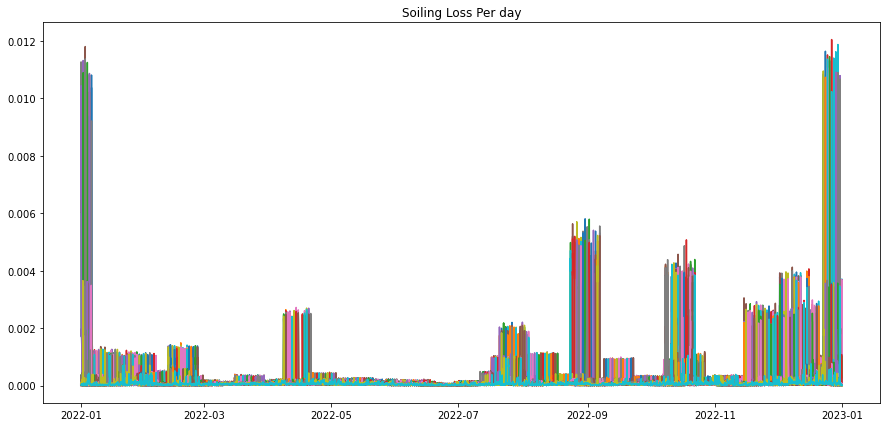

In [14]:
ax = plt.subplot()
df = opt.field_model.helios.delta_soiled_area
t = opt.simulation_data.time
for f in df.keys():
    ax.plot(t[f],df[f].mean(axis=0))

ax.set_title('Soiling Loss Per day')